# PhysioGraph Final Clean

Minimal Colab control notebook. Core logic lives in `physiograph_colab_core.py`; this notebook mounts Drive, sets project paths, runs the workflow, and displays saved outputs.

## Provenance and scope (read first)

- **This notebook is the runnable deliverable** for PhysioGraph SpO2 drilldown review.
- **Results shown below are cached/precomputed** unless you run this notebook start-to-finish in Google Colab with `BUILD_NEW=True` and fresh data paths.
- **Stored notebook outputs do not claim fresh Colab execution.** Check `fresh_colab_execution` in `run_status.json` and `spo2_drilldown/manifest.json`.
- **SpO2 analyses are observational associations**, not causal effects.
- **Respiratory/RRT controls are text-derived proxies**, not structured ventilator or dialysis records.
- **Pulse-ox instability metrics are heuristic/proxy measures**, not validated clinical scores.
- **Pooled grouped CV metrics are internal diagnostics**, not external validation.
- **CLIF dataset is out of scope** for this notebook.


In [1]:
# Mount Google Drive when running in Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as exc:
    IN_COLAB = False
    print(f'Google Drive mount skipped outside Colab: {exc}')


Google Drive mount skipped outside Colab: No module named 'google'


In [2]:
from pathlib import Path
import sys

if IN_COLAB:
    DRIVE_ROOT = Path('/content/drive/MyDrive')
    PROJECT_ROOT = DRIVE_ROOT / 'Projects' / 'PhysioGraph'
else:
    # Local: resolve the Google Drive root exactly like physiograph.config does.
    CANDIDATES = [
        Path.home() / 'Library' / 'CloudStorage' / 'GoogleDrive-2arnavmana@gmail.com' / 'My Drive',
        Path.home() / 'Library' / 'CloudStorage' / 'GoogleDrive-arnavmana@gmail.com' / 'My Drive',
        Path('/content/drive/MyDrive'),
    ]
    DRIVE_ROOT = next((p for p in CANDIDATES if p.exists()), Path.cwd())
    PROJECT_ROOT = Path.cwd()
    if not (PROJECT_ROOT / 'physiograph_colab_core.py').exists():
        PROJECT_ROOT = DRIVE_ROOT / 'Projects' / 'PhysioGraph'

MIMIC_ROOT = DRIVE_ROOT / 'Data' / 'MIMIC' / 'Full'
EICU_ROOT = DRIVE_ROOT / 'Data' / 'eICU' / 'Full'
OUTPUT_ROOT = PROJECT_ROOT / 'physiograph_outputs'

# BUILD_NEW=True rebuilds ETL from raw source CSVs (the fresh-execution gate).
# BUILD_NEW=False loads cached artifacts. Only a clean Colab run with
# BUILD_NEW=True sets fresh_colab_execution=true in the manifests.
BUILD_NEW = False

for candidate in (PROJECT_ROOT, PROJECT_ROOT / 'src'):
    candidate = candidate.resolve()
    if str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

assert (PROJECT_ROOT / 'physiograph_colab_core.py').exists(), (
    f'physiograph_colab_core.py not found under {PROJECT_ROOT}'
)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('MIMIC_ROOT   =', MIMIC_ROOT, MIMIC_ROOT.exists())
print('EICU_ROOT    =', EICU_ROOT, EICU_ROOT.exists())
print('OUTPUT_ROOT  =', OUTPUT_ROOT)
print('BUILD_NEW    =', BUILD_NEW)


PROJECT_ROOT = /Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph
MIMIC_ROOT   = /Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Data/MIMIC/Full True
EICU_ROOT    = /Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Data/eICU/Full True
OUTPUT_ROOT  = /Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph/physiograph_outputs
BUILD_NEW    = False


In [3]:
import importlib
import json
try:
    import physiograph_colab_core
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        f'{exc}: run the sys.path cell above first; PROJECT_ROOT must contain physiograph_colab_core.py'
    )

physiograph_colab_core = importlib.reload(physiograph_colab_core)
run_outputs = physiograph_colab_core.run_physiograph_colab(
    project_root=PROJECT_ROOT,
    build_new=BUILD_NEW,
    mimic_root=MIMIC_ROOT,
    eicu_root=EICU_ROOT,
    output_root=OUTPUT_ROOT,
    run_comparator=True,
)

SPO2_DIR = OUTPUT_ROOT / 'spo2_drilldown'
RUN_STATUS_PATH = OUTPUT_ROOT / 'run_status.json'
MANIFEST_PATH = SPO2_DIR / 'manifest.json'

def _load_json(path):
    if not path.exists():
        return None
    with open(path) as fh:
        return json.load(fh)

run_status = _load_json(RUN_STATUS_PATH)
manifest = _load_json(MANIFEST_PATH)

print('=== Run status / provenance ===')
if run_status:
    for key in ('fresh_colab_execution', 'build_new', 'output_root', 'project_root'):
        if key in run_status:
            print(f'  {key}: {run_status[key]}')
else:
    print(f'  run_status.json not found: {RUN_STATUS_PATH}')

if manifest:
    for key in ('fresh_colab_execution', 'build_new', 'primary_endpoint', 'analysis_layers'):
        if key in manifest:
            print(f'  manifest.{key}: {manifest[key]}')
    if manifest.get('warnings'):
        print('  manifest.warnings:')
        for w in manifest['warnings']:
            print(f'    - {w}')
    if manifest.get('notes'):
        print('  manifest.notes:')
        for n in manifest['notes']:
            print(f'    - {n}')
else:
    print(f'  manifest.json not found: {MANIFEST_PATH}')

run_outputs


/Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


findfont: Failed to find font weight normal, now using 500.


findfont: Failed to find font weight normal, now using 500.


=== Run status / provenance ===
  fresh_colab_execution: False
  build_new: False
  output_root: /Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph/physiograph_outputs
  project_root: /Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph
  manifest.fresh_colab_execution: False
  manifest.build_new: False
  manifest.primary_endpoint: lactate_rise_24h_flag
  manifest.analysis_layers: ['descriptive', 'association_or', 'predictive_cv', 'respiratory_stratified', 'availability_audit', 'external_cross_dataset', 'negative_control', 'limitations']
  manifest.warnings:
    - cached_or_precomputed_unless_fresh_colab_execution
    - text_derived_respiratory_rrt_controls_are_heuristic_proxies
    - proxy_signal_quality_when_probe_flags_absent
    - pooled_cv_is_internal_not_external_validation
    - clif_out_of_scope
    - no_causal_language
  manifest.notes:
    - No Google Colab execution is claimed unless th

{'status_path': PosixPath('/Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph/physiograph_outputs/run_status.json'),
 'output_root': PosixPath('/Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph/physiograph_outputs'),
 'spo2': {'output_dir': PosixPath('/Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph/physiograph_outputs/spo2_drilldown'),
  'paths': {'analysis_frame': PosixPath('/Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph/physiograph_outputs/spo2_drilldown/spo2_analysis_frame.csv'),
   'descriptive_summary': PosixPath('/Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/Projects/PhysioGraph/physiograph_outputs/spo2_drilldown/spo2_descriptive_summary.csv'),
   'lactate_negative_summary': PosixPath('/Users/admin/Library/CloudStorage/GoogleDrive-2arnavmana@gmail.com/My Drive/P

In [4]:
import json
import pandas as pd
from IPython.display import display

SPO2_DIR = OUTPUT_ROOT / 'spo2_drilldown'
RUN_STATUS_PATH = OUTPUT_ROOT / 'run_status.json'
MANIFEST_PATH = SPO2_DIR / 'manifest.json'


def _load_json(path):
    if not path.exists():
        return None
    with open(path) as fh:
        return json.load(fh)


def _show_csv(label, filename, *, note=None, head=25):
    print(f'\n=== {label} ===')
    if note:
        print(note)
    path = SPO2_DIR / filename
    if path.exists():
        display(pd.read_csv(path).head(head))
    else:
        print(f'Missing: {path}')


# 1) Provenance / manifest / run status
print('=== Provenance / manifest / run status ===')
run_status = _load_json(RUN_STATUS_PATH)
manifest = _load_json(MANIFEST_PATH)
if run_status:
    display(pd.DataFrame([{
        'fresh_colab_execution': run_status.get('fresh_colab_execution'),
        'build_new': run_status.get('build_new'),
        'output_root': run_status.get('output_root'),
    }]))
else:
    print(f'run_status.json not found: {RUN_STATUS_PATH}')
if manifest:
    display(pd.DataFrame([{
        'fresh_colab_execution': manifest.get('fresh_colab_execution'),
        'build_new': manifest.get('build_new'),
        'primary_endpoint': manifest.get('primary_endpoint'),
        'analysis_layers': ', '.join(manifest.get('analysis_layers', [])),
    }]))
    if manifest.get('warnings'):
        print('manifest warnings:')
        for w in manifest['warnings']:
            print(f'  - {w}')
    if manifest.get('notes'):
        print('manifest notes:')
        for n in manifest['notes']:
            print(f'  - {n}')
else:
    print(f'manifest.json not found: {MANIFEST_PATH}')

# 2) Availability audit
_show_csv('SpO2 availability audit', 'spo2_availability_audit.csv')

# 3) Primary CV / model metrics (internal grouped / out-of-fold if generated)
_show_csv(
    'SpO2 model metrics (primary endpoint)',
    'spo2_model_metrics.csv',
    note=(
        'WARNING: metrics here are internal grouped / out-of-fold diagnostics when generated; '
        'not external validation and not causal performance claims.'
    ),
)

# 4) Adjusted OR / p-values per feature
_show_csv('Adjusted OR / p-values per feature', 'spo2_or_pvalues_adjusted_per_feature.csv')

# 5) Respiratory context (optional)
_show_csv('Respiratory context (text-derived proxies)', 'spo2_respiratory_context.csv')

# 6) Lactate negative results
_show_csv('Lactate negative-control results', 'spo2_lactate_negative_results.csv')

# 7) External cross-dataset (optional)
print('\n=== External cross-dataset check ===')
ext_path = SPO2_DIR / 'spo2_external_cross_dataset.csv'
if ext_path.exists():
    display(pd.read_csv(ext_path).head(25))
else:
    print('spo2_external_cross_dataset.csv unavailable (not generated in this output tree).')

# 8) Missingness negative control (optional)
print('\n=== Missingness negative control ===')
miss_path = SPO2_DIR / 'spo2_missingness_negative_control.csv'
if miss_path.exists():
    display(pd.read_csv(miss_path).head(25))
else:
    print('spo2_missingness_negative_control.csv not run / not present in this output tree.')

# 9) Claims linter warnings
_show_csv('Claims linter warnings', 'claims_linter_warnings.csv')

# 10) Exploratory / context tables
_show_csv('Descriptive summary (exploratory)', 'spo2_descriptive_summary.csv')
_show_csv('Variability group summary (exploratory)', 'spo2_variability_group_summary.csv')


=== Provenance / manifest / run status ===


,fresh_colab_execution,build_new,output_root
0,False,False,/Users/admin/Library/CloudStorage/GoogleDrive-...


,fresh_colab_execution,build_new,primary_endpoint,analysis_layers
0,False,False,lactate_rise_24h_flag,"descriptive, association_or, predictive_cv, re..."


manifest warnings:
  - cached_or_precomputed_unless_fresh_colab_execution
  - text_derived_respiratory_rrt_controls_are_heuristic_proxies
  - proxy_signal_quality_when_probe_flags_absent
  - pooled_cv_is_internal_not_external_validation
  - clif_out_of_scope
  - no_causal_language
manifest notes:
  - No Google Colab execution is claimed unless the notebook is run in Colab.
  - Grouped CV metrics are internal pooled estimates, not external validation.
  - Preprocessing is fitted independently within each patient-grouped training fold.
  - Calibration/ECE uses out-of-fold predictions only.
  - Text-derived respiratory/RRT controls are heuristic proxies.
  - CLIF dataset is out of scope.

=== SpO2 availability audit ===


,dataset,n_rows,spo2_measured_rows,spo2_zero_plausible_rows,fio2_available_rows,respiratory_support_rows,mechanical_ventilation_rows,rrt_or_dialysis_rows,vis_12h_observed_rows,vis_24h_observed_rows,...,hepatic_lab_worsening_24h_flag_event_rate,hepatic_lab_worsening_24h_flag_events,mcs_12h_flag_event_rate,mcs_12h_flag_events,mcs_24h_flag_event_rate,mcs_24h_flag_events,early_decompensation_12h_flag_event_rate,early_decompensation_12h_flag_events,early_decompensation_24h_flag_event_rate,early_decompensation_24h_flag_events
0,mimic,240,0,240,0,0,0,0,240,240,...,NaN,0,0.0,0,0.004167,1,0.087500,21,0.104167,25
1,eicu,300,93,207,0,0,0,0,0,0,...,0.307692,4,0.0,0,0.000000,0,0.103333,31,0.166667,50


...

,severity,check,detail
0,warning,fresh_colab_execution,fresh_colab_execution is False; metrics are lo...
1,info,manifest_policy,cached_or_precomputed_unless_fresh_colab_execu...
2,info,manifest_policy,text_derived_respiratory_rrt_controls_are_heur...
3,info,manifest_policy,proxy_signal_quality_when_probe_flags_absent
4,info,manifest_policy,pooled_cv_is_internal_not_external_validation
5,info,manifest_policy,clif_out_of_scope
6,info,manifest_policy,no_causal_language
7,warning,primary_endpoint_not_adequately_observed,eicu: lactate_rise_12h_flag (fragile_or_underp...
8,warning,primary_endpoint_not_adequately_observed,eicu: lactate_rise_24h_flag (fragile_or_underp...
9,warning,primary_endpoint_not_adequately_observed,eicu: vis_rise_12h_flag (fragile_or_underpowered)



=== Descriptive summary (exploratory) ===


,group_column,group_value,n,spo2_min_mean,spo2_min_median,spo2_mean_mean,spo2_mean_median,spo2_sd_mean,spo2_sd_median,spo2_rmssd_mean,spo2_rmssd_median,spo2_below_90_fraction_mean,spo2_below_90_fraction_median,spo2_sampling_density_per_hr_mean,spo2_sampling_density_per_hr_median,spo2_instability_proxy_score_mean,spo2_instability_proxy_score_median
0,target,0,437,91.535211,93.0,96.933766,97.311111,1.632808,1.224556,1.540451,1.048809,0.020509,0.000000,1.683066,0.0,1.990317,1.00000
1,target,1,103,89.045455,92.0,95.505715,96.894773,2.782848,1.462172,2.638667,1.259393,0.086777,0.000000,2.116505,0.0,2.036932,1.03125
2,mcs_48h_flag,0,538,90.946237,93.0,96.595947,97.217391,1.904860,1.288963,1.800244,1.093459,0.036185,0.000000,1.772305,0.0,2.001344,1.00000
3,mcs_48h_flag,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN
4,mcs_72h_flag,0,538,90.946237,93.0,96.595947,97.217391,1.904860,1.288963,1.800244,1.093459,0.036185,0.000000,1.772305,0.0,2.001344,1.00000
5,mcs_72h_flag,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN
6,mcs_96h_flag,0,538,90.946237,93.0,96.595947,97.217391,1.904860,1.288963,1.800244,1.093459,0.036185,0.000000,1.772305,0.0,2.001344,1.00000
7,mcs_96h_flag,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN
8,mcs_168h_flag,0,538,90.946237,93.0,96.595947,97.217391,1.904860,1.288963,1.800244,1.093459,0.036185,0.000000,1.772305,0.0,2.001344,1.00000
9,mcs_168h_flag,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,NaN,NaN



=== Variability group summary (exploratory) ===


,outcome,feature,n_total,n_non_event,n_event,mean_non_event,mean_event,median_non_event,median_event,mean_ratio_event_vs_non_event,mean_pct_change_event_vs_non_event
0,aki_creatinine_24h_flag,spo2_iqr,15,13,2,1.692308,0.500000,1.000000,0.500000,0.295455,-70.454545
1,aki_creatinine_24h_flag,spo2_mad,15,13,2,0.846154,0.000000,1.000000,0.000000,0.000000,-100.000000
2,aki_creatinine_24h_flag,spo2_range,15,13,2,8.769231,9.000000,5.000000,9.000000,1.026316,2.631579
3,aki_creatinine_24h_flag,spo2_rmssd,15,13,2,1.822035,2.176347,1.160959,2.176347,1.194459,19.445949
4,aki_creatinine_24h_flag,spo2_sd,15,13,2,1.871019,1.497746,1.202834,1.497746,0.800498,-19.950249
5,early_decompensation_12h_flag,spo2_iqr,93,80,13,1.934375,1.673077,1.000000,1.250000,0.864919,-13.508140
6,early_decompensation_12h_flag,spo2_mad,93,80,13,0.993750,0.846154,1.000000,1.000000,0.851476,-14.852443
7,early_decompensation_12h_flag,spo2_range,93,80,13,8.012500,7.384615,5.500000,7.000000,0.921637,-7.836313
8,early_decompensation_12h_flag,spo2_rmssd,93,80,13,1.820819,1.673630,1.056014,1.454058,0.919163,-8.083680
9,early_decompensation_12h_flag,spo2_sd,93,80,13,1.939884,1.689333,1.240368,1.422692,0.870843,-12.915743


=== Exploratory figures (descriptive; not validation) ===
spo2_low_burden_by_outcome.png


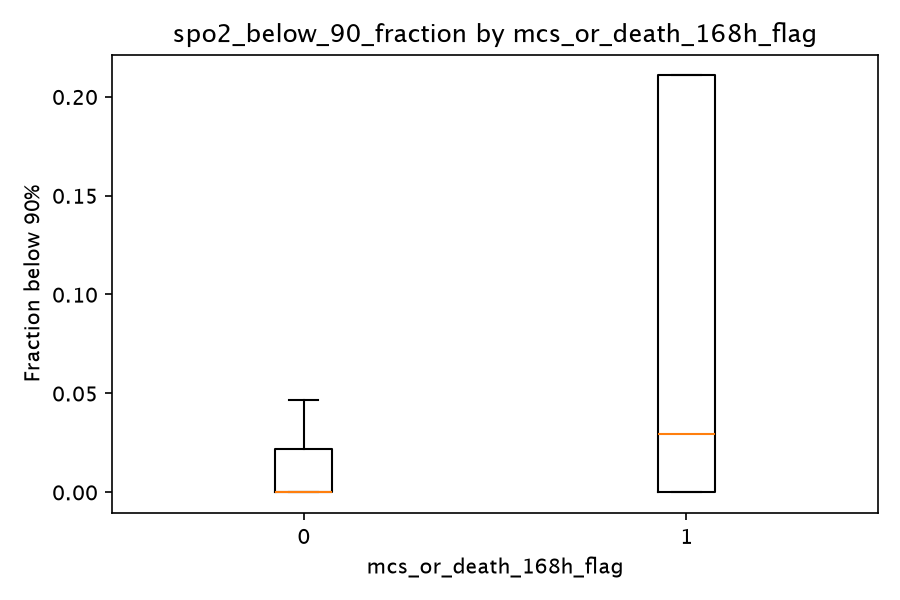

spo2_sampling_density_by_outcome.png


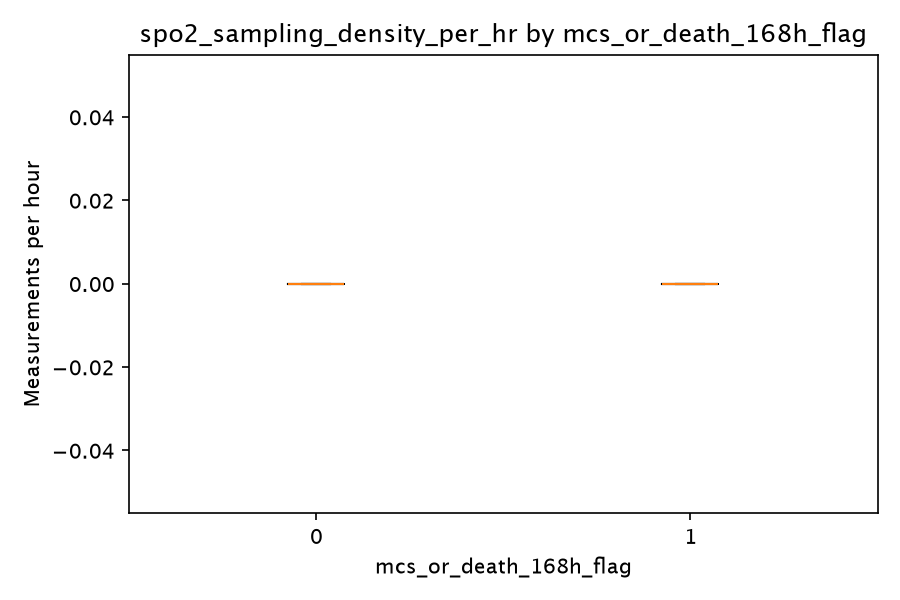

spo2_variability_by_outcome.png


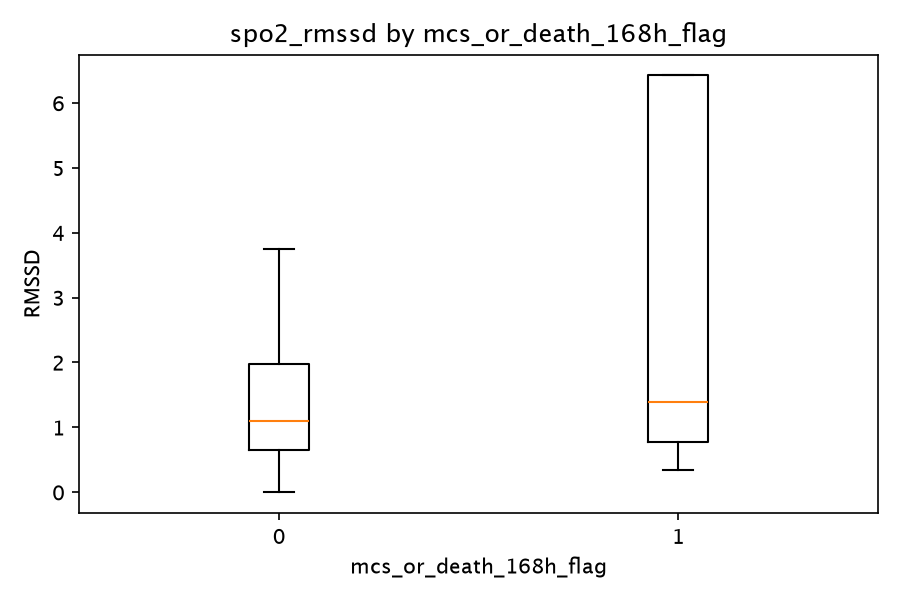

In [5]:
from IPython.display import Image, display

print('=== Exploratory figures (descriptive; not validation) ===')
FIGURE_DIR = SPO2_DIR / 'figures'
if FIGURE_DIR.exists():
    for path in sorted(FIGURE_DIR.glob('*.png')):
        print(path.name)
        display(Image(filename=str(path)))
else:
    print(f'No figures directory: {FIGURE_DIR}')
